# 10 — Correlation Between Image Type Distance Matrices

Measures how similar the **pairwise patient distances** are across the 5 MRI image types.
A high Pearson correlation between two image types means that patients who are far apart
in one imaging plane are also far apart in the other — the two planes carry redundant information.
A low correlation means each plane captures something unique about brain structure.

In [3]:
import subprocess, sys

def run_pip(*args):
    cmd = [sys.executable, "-m", "pip", "install", "--quiet"] + list(args)
    r   = subprocess.run(cmd, capture_output=True, text=True)
    tag = args[-1]
    if r.returncode == 0:
        print(f"  OK    {tag}")
    else:
        print(f"  FAIL  {tag}")
        print(r.stderr[-400:] if r.stderr else "(no stderr)")

for pkg in ["seaborn", "scipy"]:
    run_pip(pkg)
print("Done.")

  OK    seaborn
  OK    scipy
Done.


## Imports

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr

print("All imports successful.")

All imports successful.


## Step 1 — Load all 5 PCA files

Each file is 416 × 111 (patient_id + 110 PCA components).  
Drop `patient_id` to get the 416 × 110 feature matrix.

In [5]:
NB_FOLDER = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NB_FOLDER, '..', '..'))
DATA_PIPELINE_DIR = os.path.join(PROJECT_ROOT, 'notebooks', '01_data_pipeline')
OUTPUT_DIR = NB_FOLDER
NB_DIR = DATA_PIPELINE_DIR      # legacy alias: shared pipeline inputs (pca_*.csv, clinical xlsx)
NB_PADDED = OUTPUT_DIR          # legacy alias: this notebook's own outputs

PCA_FILES = {
    "cor":        "pca_cor.csv",
    "gfc_sag":    "pca_gfc_sag.csv",
    "gfc_tra":    "pca_gfc_tra.csv",
    "masked_tra": "pca_masked_tra.csv",
    "sbj_sag":    "pca_sbj_sag.csv",
}

pca_matrices = {}   # image_type → np.ndarray (416, 110)

for itype, fname in PCA_FILES.items():
    df  = pd.read_csv(os.path.join(NB_DIR, fname))
    X   = df.drop(columns=["patient_id"]).to_numpy(dtype=np.float64)
    pca_matrices[itype] = X
    print(f"  {itype:<14} shape={X.shape}  NaN={np.isnan(X).sum()}")

print(f"\nAll 5 PCA matrices loaded.")

  cor            shape=(416, 110)  NaN=0
  gfc_sag        shape=(416, 110)  NaN=0
  gfc_tra        shape=(416, 110)  NaN=0
  masked_tra     shape=(416, 110)  NaN=0
  sbj_sag        shape=(416, 110)  NaN=0

All 5 PCA matrices loaded.


## Step 2 — Compute Euclidean distance matrix for each image type

Each distance matrix is 416 × 416 — one entry per pair of patients.

In [6]:
def compute_distance_matrix(X):
    return squareform(pdist(X, metric="euclidean"))

dist_matrices = {}   # image_type → np.ndarray (416, 416)

for itype, X in pca_matrices.items():
    D = compute_distance_matrix(X)
    dist_matrices[itype] = D
    print(f"  {itype:<14} D shape={D.shape}  "
          f"range=[{D.min():.4f}, {D.max():.4f}]  "
          f"symmetric={np.allclose(D, D.T)}")

print("\nAll 5 distance matrices computed.")

  cor            D shape=(416, 416)  range=[0.0000, 10.5901]  symmetric=True
  gfc_sag        D shape=(416, 416)  range=[0.0000, 9.9137]  symmetric=True
  gfc_tra        D shape=(416, 416)  range=[0.0000, 10.2192]  symmetric=True
  masked_tra     D shape=(416, 416)  range=[0.0000, 7.3766]  symmetric=True
  sbj_sag        D shape=(416, 416)  range=[0.0000, 14.8972]  symmetric=True

All 5 distance matrices computed.


## Step 3 — Flatten upper triangles and compute Pearson correlations

A 416 × 416 distance matrix has 416 × 415 / 2 = **86,320** unique patient pairs
in its upper triangle (excluding the diagonal, which is always zero).
Each distance matrix is flattened to an 86,320-element vector.  
The Pearson correlation between two such vectors measures how consistently
patient pairs that are distant in one imaging plane are also distant in the other.

In [7]:
image_names = list(PCA_FILES.keys())
D_list      = [dist_matrices[t] for t in image_names]
n_patients  = D_list[0].shape[0]

# Upper triangle indices (excluding diagonal)
idx     = np.triu_indices(n_patients, k=1)
vectors = [D[idx] for D in D_list]

print(f"Upper triangle size : {len(vectors[0]):,} patient pairs")
print(f"Computing 5×5 Pearson correlation matrix ...")

corr_matrix = np.zeros((5, 5))
p_matrix    = np.zeros((5, 5))

for i in range(5):
    for j in range(5):
        r, p = pearsonr(vectors[i], vectors[j])
        corr_matrix[i, j] = r
        p_matrix[i, j]    = p

df_corr = pd.DataFrame(corr_matrix, index=image_names, columns=image_names)
print("\nDone.")

Upper triangle size : 86,320 patient pairs
Computing 5×5 Pearson correlation matrix ...

Done.


## Step 4 — Heatmap

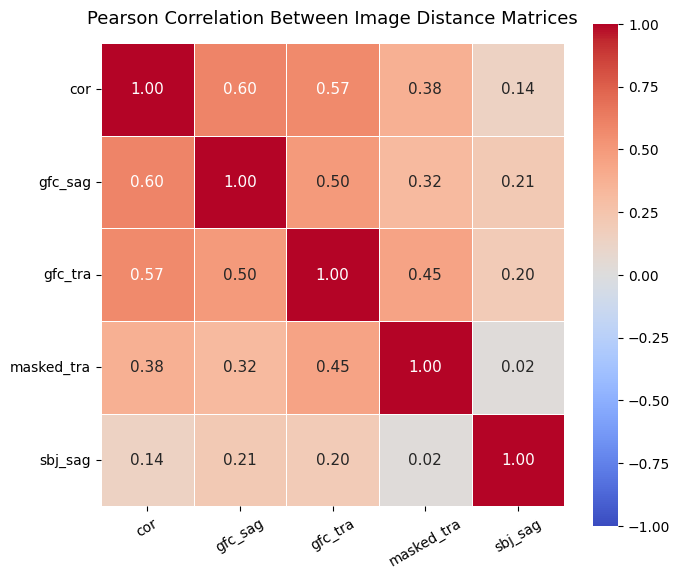

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\image_correlation_heatmap.png


In [8]:
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    df_corr,
    annot=True,
    fmt=".2f",
    vmin=-1, vmax=1,
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white",
    square=True,
    ax=ax,
    annot_kws={"size": 11},
)

ax.set_title("Pearson Correlation Between Image Distance Matrices", fontsize=13, pad=14)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=30, labelsize=10)
ax.tick_params(axis="y", rotation=0,  labelsize=10)

plt.tight_layout()

heatmap_path = os.path.join(NB_PADDED, "image_correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {heatmap_path}")

## Step 5 — Interpretation

In [9]:
print("Full correlation matrix:")
print(df_corr.round(4).to_string())

# Extract off-diagonal values (unique pairs only)
pairs = []
for i in range(5):
    for j in range(i + 1, 5):
        pairs.append({
            "pair":        f"{image_names[i]}  ↔  {image_names[j]}",
            "correlation": round(corr_matrix[i, j], 4),
        })

df_pairs = pd.DataFrame(pairs).sort_values("correlation", ascending=False).reset_index(drop=True)

print("\nAll pairwise correlations (sorted highest → lowest):")
print(df_pairs.to_string(index=False))

highest = df_pairs.iloc[0]
lowest  = df_pairs.iloc[-1]

print(f"\nHighest correlation : {highest['pair']}  →  r = {highest['correlation']:.4f}")
print(f"  These two image types carry the most REDUNDANT information.")
print(f"\nLowest correlation  : {lowest['pair']}  →  r = {lowest['correlation']:.4f}")
print(f"  These two image types carry the most COMPLEMENTARY information.")

Full correlation matrix:
               cor  gfc_sag  gfc_tra  masked_tra  sbj_sag
cor         1.0000   0.5981   0.5735      0.3808   0.1374
gfc_sag     0.5981   1.0000   0.4957      0.3158   0.2132
gfc_tra     0.5735   0.4957   1.0000      0.4474   0.1974
masked_tra  0.3808   0.3158   0.4474      1.0000   0.0161
sbj_sag     0.1374   0.2132   0.1974      0.0161   1.0000

All pairwise correlations (sorted highest → lowest):
                  pair  correlation
       cor  ↔  gfc_sag       0.5981
       cor  ↔  gfc_tra       0.5735
   gfc_sag  ↔  gfc_tra       0.4957
gfc_tra  ↔  masked_tra       0.4474
    cor  ↔  masked_tra       0.3808
gfc_sag  ↔  masked_tra       0.3158
   gfc_sag  ↔  sbj_sag       0.2132
   gfc_tra  ↔  sbj_sag       0.1974
       cor  ↔  sbj_sag       0.1374
masked_tra  ↔  sbj_sag       0.0161

Highest correlation : cor  ↔  gfc_sag  →  r = 0.5981
  These two image types carry the most REDUNDANT information.

Lowest correlation  : masked_tra  ↔  sbj_sag  →  r = 0.0161
